In [12]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools, Descriptors, rdchem, rdMolDescriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np
from sklearn.model_selection import cross_validate, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [13]:
def mol_to_feat(mol):
    #找我认为的重要键
    NO_single = NO_double = 0
    NN_single = NN_double = 0
    sum = 0
    for i in mol.GetBonds():
        pre = i.GetBeginAtom().GetSymbol()
        nxt = i.GetEndAtom().GetSymbol()
        link = i.GetBondType()
        if pre == "O":
            pre, nxt = nxt, pre
        if pre == "N" and nxt == "O":
            if link == rdchem.BondType.SINGLE:
                NO_single += 1
            else:
                NO_double += 1
        elif pre == "N" and nxt == "N":
            if link == rdchem.BondType.SINGLE:
                NN_single += 1
            else:
                NN_double += 1
        sum += 1

    #算各种原子的个数
    mqn = rdMolDescriptors.MQNs_(mol)
    N = mqn[7] + mqn[8]
    O = mqn[9] + mqn[10]
    C = mqn[0]
    mol = Chem.AddHs(mol)
    H = mol.GetNumAtoms() - mol.GetNumHeavyAtoms()
    
    feat = [
        (C * 2 + H / 2 - O) * 16 / Descriptors.MolWt(mol),
        Descriptors.fr_Ar_N(mol) * 14 / Descriptors.MolWt(mol),
        # NO_double / sum, NN_single, NN_double
    ]
    
    desc_names = [
        'fr_bicyclic', 'BCUT2D_MRHI', 'BCUT2D_LOGPLOW', 'PEOE_VSA7',
        'VSA_EState4', 'MinEStateIndex', 'PEOE_VSA10', 'PEOE_VSA11',
        'PEOE_VSA3', 'EState_VSA8', 'BCUT2D_CHGHI', 'AvgIpc', 'EState_VSA2',
        'PEOE_VSA13', 'SlogP_VSA6', 'SMR_VSA7', 'fr_NH0'
    ]
    feat = feat + list(MoleculeDescriptors.MolecularDescriptorCalculator(desc_names).CalcDescriptors(mol))
    
    return feat

In [14]:
file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "ROMol", False)
x_all = np.stack(df["ROMol"].apply(mol_to_feat).tolist(), axis = 0)
y_all = np.array(df["Td(°C)"], dtype = np.float64)

rf = RandomForestRegressor(
    n_estimators = 300,
    n_jobs = -1,
    random_state = 114514
)

scores = cross_validate(
    rf, x_all, y_all, 
    cv = KFold(n_splits = 10, shuffle = True, random_state = 323922),
    scoring = ["neg_mean_squared_error", "neg_mean_absolute_error", "r2"], 
    n_jobs = -1
)
rmse = ((-scores["test_neg_mean_squared_error"]) ** 0.5).mean()
mae = np.abs(scores["test_neg_mean_absolute_error"]).mean()
r2 = scores["test_r2"]
print(rmse, mae, r2.mean(), r2.std(), r2, sep = '\n')

41.6291383243131
31.131758222800606
0.59752278902418
0.025264927345426392
[0.58372448 0.57878578 0.57953684 0.60397948 0.58750362 0.60274267
 0.65122053 0.6267171  0.5577692  0.6032482 ]


0.5142103308226795 33.604369630966445 44.43042468232153


,x_test,y_test,predict
877,,168.80,172.706000
846,,172.00,205.678667
1333,,120.00,143.799367
776,,180.00,171.239593
1233,,133.00,148.902800
707,,187.39,177.882044
1102,,146.50,128.124683
1145,,141.00,133.788533
580,,202.00,132.436433
567,,204.70,231.249133

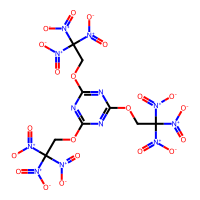
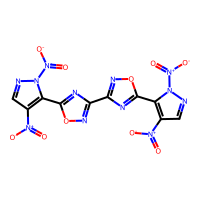
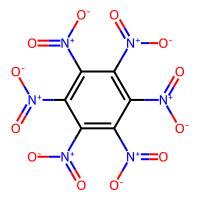
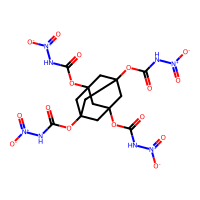
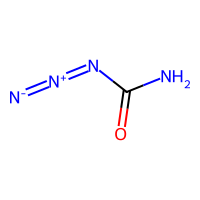
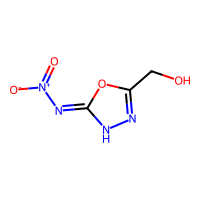
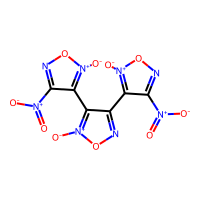
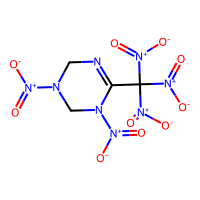
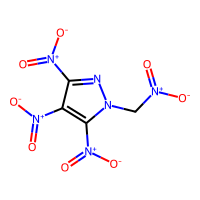
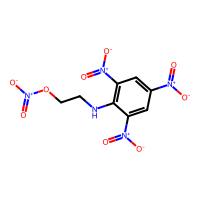
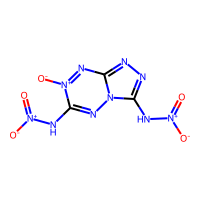
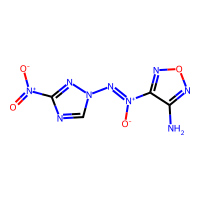
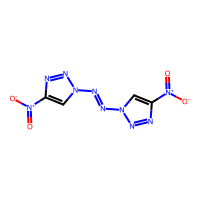
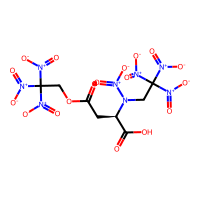
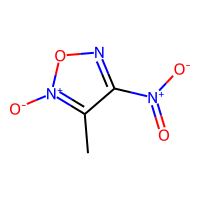
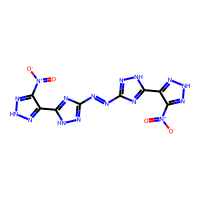
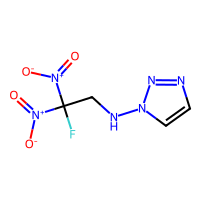
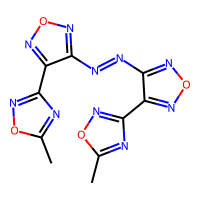
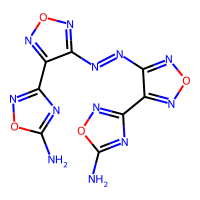
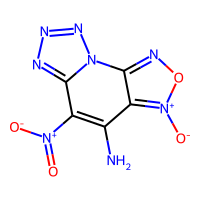
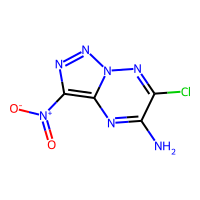
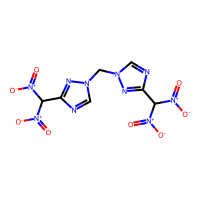
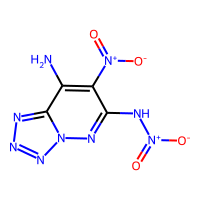
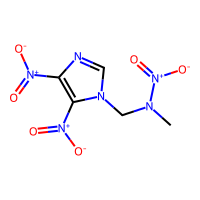
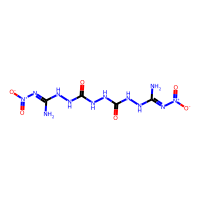
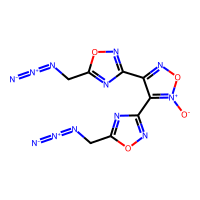
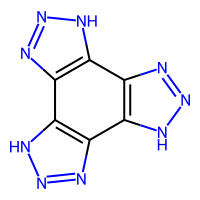
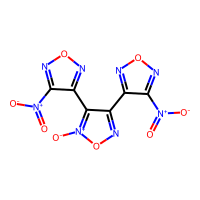
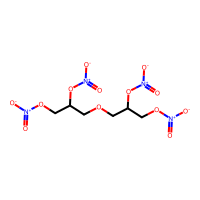
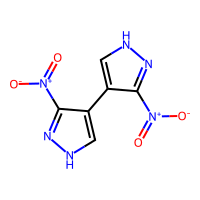

In [15]:
file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "ROMol", False)
x_train, x_test, y_train, y_test = train_test_split(df["ROMol"], df["Td(°C)"])
df1 = pd.DataFrame({
    'x_test': x_test,
    'y_test': y_test
})

rf = RandomForestRegressor(
    n_estimators = 300,
    n_jobs = -1,
    random_state = 114514
)

x_train = np.stack([mol_to_feat(mol) for mol in x_train], axis = 0)
x_train = StandardScaler().fit_transform(x_train)
x_test = np.stack([mol_to_feat(mol) for mol in x_test], axis = 0)
x_test = StandardScaler().fit_transform(x_test)

rf.fit(x_train, y_train)
y_pre = rf.predict(x_test)

PandasTools.RenderImagesInAllDataFrames(images = True)
df1["predict"] = y_pre
print(r2_score(y_test, y_pre), mean_absolute_error(y_test, y_pre), mean_squared_error(y_test, y_pre) ** 0.5)
df1[ : 30]